# Objective 1: Import & QA the Data

## First objective is to import & join two customer data tables, then remove duplicate rows & columns and fill in missing values.

### Task : To explore and prepare a set of customer data that will be used for Machine Learning models to churn prediction and customer segmentation

### Import the data from both tabs in the "Bank_Churn_Messy" Excel file

In [1]:
pip install openpyxl


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

In [3]:
cust_churn = pd.read_excel('Bank_Churn_Messy.xlsx')

In [4]:
cust_churn.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1


In [5]:
cust_act = pd.read_excel('Bank_Churn_Messy.xlsx',sheet_name=1)

In [6]:
cust_act.head()

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
2,15647311,€83807.86,1,Yes,1,Yes,0
3,15619304,€159660.8,3,No,8,No,1
4,15701354,€0.0,2,No,1,No,0


### Use a left join to join "Account_Info" to "Customer_Info" using the CustomerID column

In [7]:
churn_df = cust_churn.merge(cust_act, how="left", on="CustomerId")

In [8]:
churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
1,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,1,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,8,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,1,No,0


In [9]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10004 entries, 0 to 10003
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10004 non-null  int64  
 1   Surname          10001 non-null  object 
 2   CreditScore      10004 non-null  int64  
 3   Geography        10004 non-null  object 
 4   Gender           10004 non-null  object 
 5   Age              10001 non-null  float64
 6   Tenure_x         10004 non-null  int64  
 7   EstimatedSalary  10004 non-null  object 
 8   Balance          10004 non-null  object 
 9   NumOfProducts    10004 non-null  int64  
 10  HasCrCard        10004 non-null  object 
 11  Tenure_y         10004 non-null  int64  
 12  IsActiveMember   10004 non-null  object 
 13  Exited           10004 non-null  int64  
dtypes: float64(1), int64(6), object(7)
memory usage: 1.1+ MB


### Check for and remove duplicate rows and columns

In [10]:
churn_df = churn_df.drop("Tenure_y",axis=1).rename({"Tenure_x":"Tenure"},axis=1)

In [11]:
churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,Yes,1
1,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,No,0


In [12]:
churn_df.duplicated(keep=False)

0         True
1         True
2        False
3        False
4        False
         ...  
9999     False
10000     True
10001     True
10002     True
10003     True
Length: 10004, dtype: bool

In [13]:
churn_df.tail()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
9999,15682355,Sabbatini,772,Germany,Male,42.0,3,€92888.52,€75075.31,2,No,No,1
10000,15628319,Walker,792,French,Female,28.0,4,€38190.78,€130142.79,1,No,No,0
10001,15628319,Walker,792,French,Female,28.0,4,€38190.78,€130142.79,1,No,No,0
10002,15628319,Walker,792,French,Female,28.0,4,€38190.78,€130142.79,1,No,No,0
10003,15628319,Walker,792,French,Female,28.0,4,€38190.78,€130142.79,1,No,No,0


In [14]:
churn_df = churn_df.drop_duplicates()

In [15]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              9997 non-null   float64
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  object 
 8   Balance          10000 non-null  object 
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 1.1+ MB


# Objective 2 : Clean the data
## The objective is to clean the data by fixing inconsistencies in labeling, handling erroneous values, and fixing currency fields.

### Task 
### Check the data types for each column and make any necessary fixes

In [16]:
churn_df.dtypes

CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                float64
Tenure               int64
EstimatedSalary     object
Balance             object
NumOfProducts        int64
HasCrCard           object
IsActiveMember      object
Exited               int64
dtype: object

In [17]:
churn_df.EstimatedSalary = churn_df.EstimatedSalary.str.replace('€','').astype('float')

In [18]:
churn_df.Balance = churn_df.Balance.str.replace('€','').astype('float')

In [19]:
churn_df.Age = churn_df.Age.astype('Int64')

In [20]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              9997 non-null   Int64  
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: Int64(1), float64(2), int64(5), object(5)
memory usage: 1.1+ MB


### Replace missing values in categorical columns with "MISSING", and missing values in numeric columns with the median

In [21]:
churn_df[churn_df.isna().any(axis=1) == True]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
29,15728693,NaN,574,Germany,Female,<NA>,3,-999999.0,141349.43,1,Yes,Yes,0
122,15580203,NaN,674,Spain,Male,<NA>,6,-999999.0,120193.42,1,No,No,0
9390,15756954,NaN,538,France,Female,<NA>,2,-999999.0,0.00,1,Yes,Yes,0


In [22]:
churn_df = churn_df.fillna(value= {'Surname':"MISSING","Age":churn_df.Age.median()})

churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  Int64  
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: Int64(1), float64(2), int64(5), object(5)
memory usage: 1.1+ MB


In [23]:
churn_df.iloc[[28,121,9389]]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
29,15728693,MISSING,574,Germany,Female,37,3,-999999.0,141349.43,1,Yes,Yes,0
122,15580203,MISSING,674,Spain,Male,37,6,-999999.0,120193.42,1,No,No,0
9390,15756954,MISSING,538,France,Female,37,2,-999999.0,0.00,1,Yes,Yes,0


### Profile the numeric columns in the data. Are there any extreme or non-sensical values? If so, impute them with the median of the column.

In [24]:
churn_df.describe()

,CustomerId,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited
count,1.000000e+04,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.9215,5.012800,99762.195289,76485.889288,1.530200,0.203700
std,7.193619e+04,96.653299,10.487552,2.892174,60583.863580,62397.405202,0.581654,0.402769
min,1.556570e+07,350.000000,18.0,0.000000,-999999.000000,0.000000,1.000000,0.000000
25%,1.562853e+07,584.000000,32.0,3.000000,50910.677500,0.000000,1.000000,0.000000
50%,1.569074e+07,652.000000,37.0,5.000000,100191.725000,97198.540000,1.000000,0.000000
75%,1.575323e+07,718.000000,44.0,7.000000,149388.247500,127644.240000,2.000000,0.000000
max,1.581569e+07,850.000000,92.0,10.000000,199992.480000,250898.090000,4.000000,1.000000


In [25]:
churn_df['EstimatedSalary'] = churn_df['EstimatedSalary'].replace(-999999.000000,churn_df['EstimatedSalary'].median())

churn_df.describe()

,CustomerId,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited
count,1.000000e+04,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.9215,5.012800,100092.252506,76485.889288,1.530200,0.203700
std,7.193619e+04,96.653299,10.487552,2.892174,57510.146401,62397.405202,0.581654,0.402769
min,1.556570e+07,350.000000,18.0,0.000000,11.580000,0.000000,1.000000,0.000000
25%,1.562853e+07,584.000000,32.0,3.000000,51002.110000,0.000000,1.000000,0.000000
50%,1.569074e+07,652.000000,37.0,5.000000,100196.062500,97198.540000,1.000000,0.000000
75%,1.575323e+07,718.000000,44.0,7.000000,149388.247500,127644.240000,2.000000,0.000000
max,1.581569e+07,850.000000,92.0,10.000000,199992.480000,250898.090000,4.000000,1.000000


### Combine any variations in country names in the "Geography" column to a single value per country

In [26]:
churn_df['Geography'].value_counts()

Geography
Germany    2509
Spain      2477
France     1741
French     1655
FRA        1618
Name: count, dtype: int64

In [27]:
import numpy as np
churn_df['Geography'] = np.where(churn_df['Geography'].isin(["French","France","FRA"]),"France",churn_df['Geography'])

churn_df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

# Objective 3:  Explore the data
## Now it is time to explore the target variable and look at feature-target relationships for categorical and numeric fields.

### Build a bar chart displaying the count of churners (Exited=1) vs. non-churners (Exited=0)

In [28]:
pip install matplotlib


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


<Axes: xlabel='Exited'>

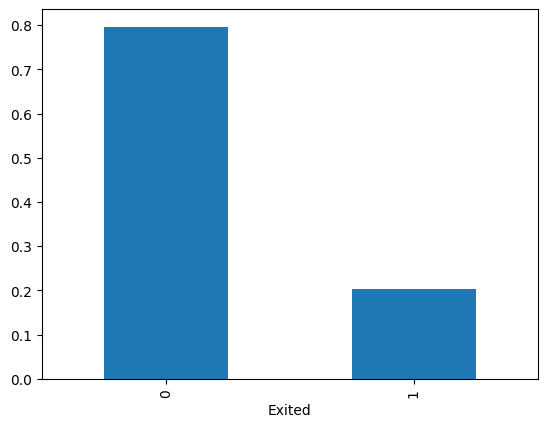

In [30]:
import matplotlib.pyplot as plt

churn_df['Exited'].value_counts(normalize = True).plot.bar()

### Explore the categorical variables vs. the target, and look at the percentage of Churners by “Geography” and “Gender”

In [32]:
pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 2.8 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
churn_df.select_dtypes("object")

,Surname,Geography,Gender,HasCrCard,IsActiveMember
0,Hargrave,France,Female,Yes,Yes
2,Hill,Spain,Female,Yes,Yes
3,Onio,France,Female,No,No
4,Boni,France,Female,No,No
5,Mitchell,Spain,Female,Yes,Yes
...,...,...,...,...,...
9996,Obijiaku,France,Male,No,No
9997,Johnstone,France,Male,Yes,Yes
9998,Liu,France,Female,Yes,Yes
9999,Sabbatini,Germany,Male,No,No


<Axes: xlabel='Geography', ylabel='Exited'>

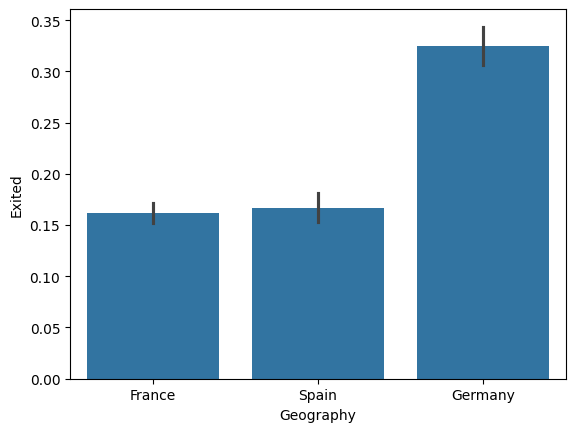

In [46]:
    sns.barplot(data=churn_df,x="Geography",y='Exited')

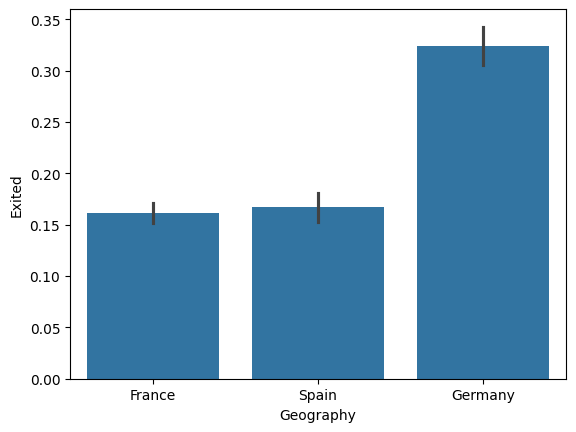

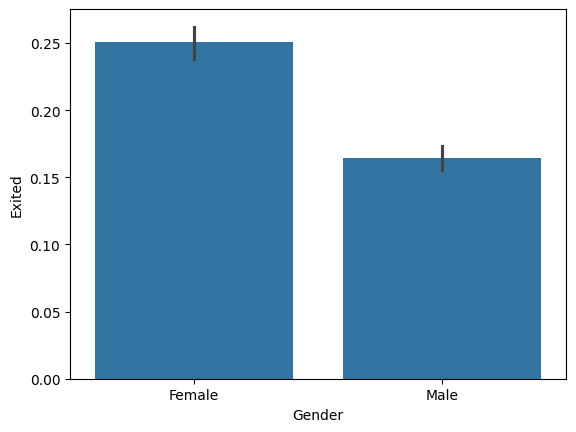

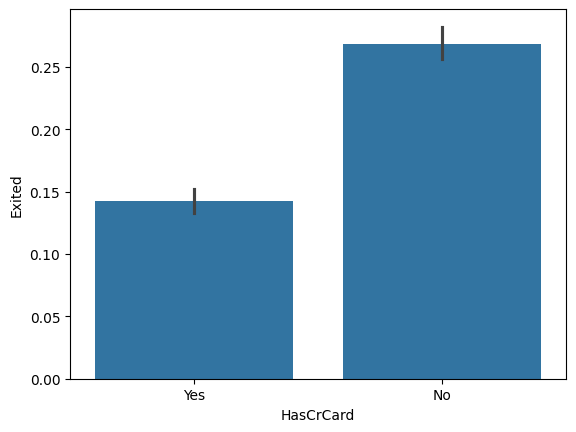

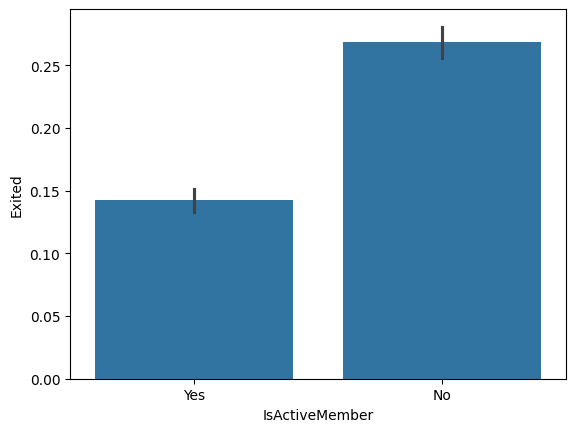

In [39]:
import seaborn as sns

for col in churn_df.drop("Surname",axis=1).select_dtypes("object"):
    
    sns.barplot(data=churn_df,x=col,y='Exited')
    plt.show()

### Build box plots for each numeric field, broken out by churners vs. non-churners

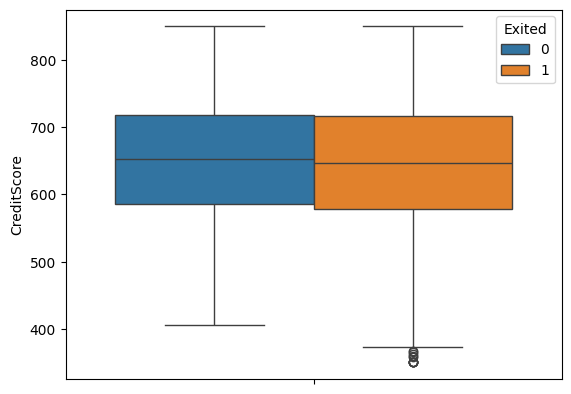

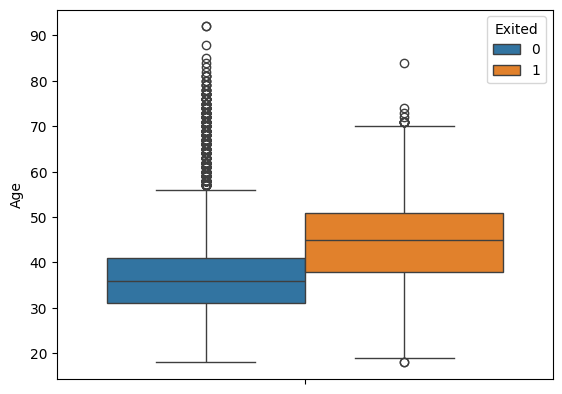

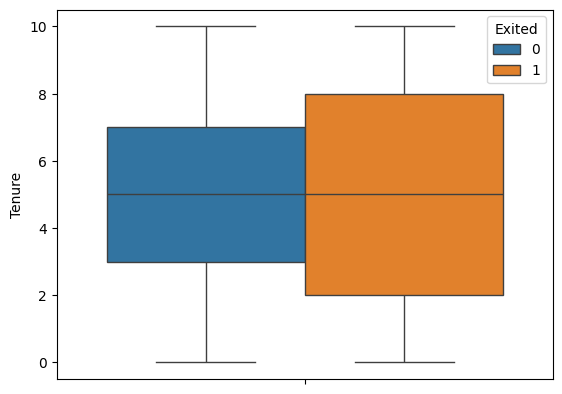

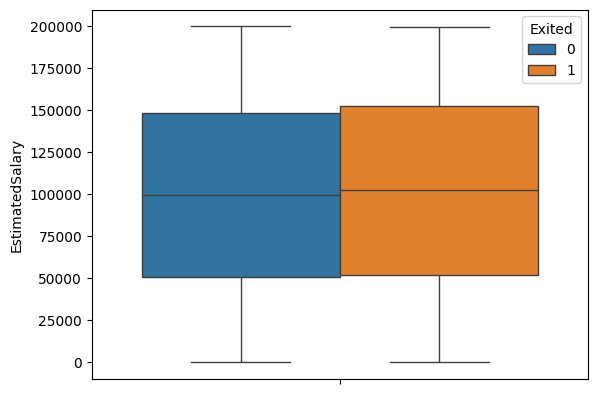

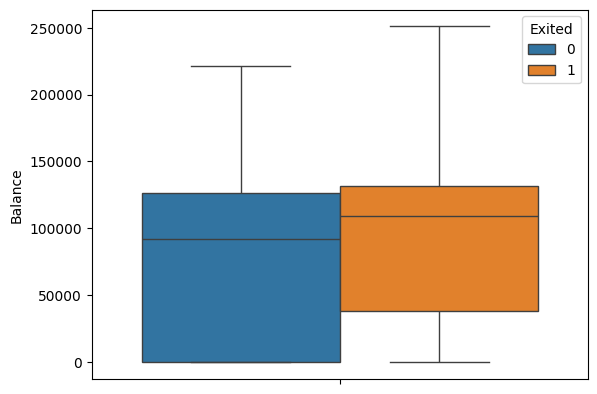

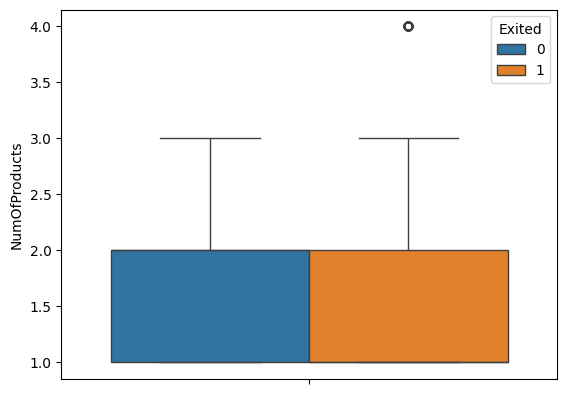

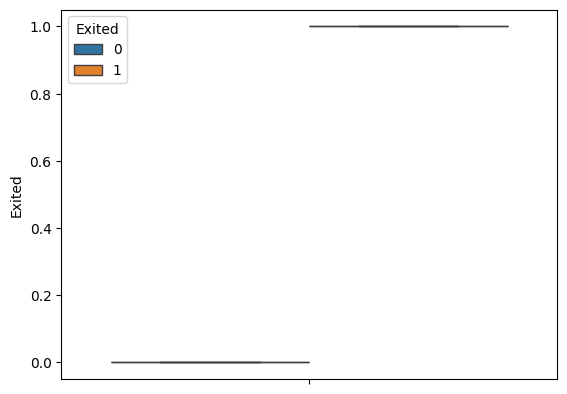

In [42]:


for col in churn_df.drop("CustomerId",axis=1).select_dtypes("number"):
    sns.boxplot(data=churn_df,y=col,hue="Exited")
    plt.show()

### Build histograms for each numeric field, broken out by churners vs. non-churners

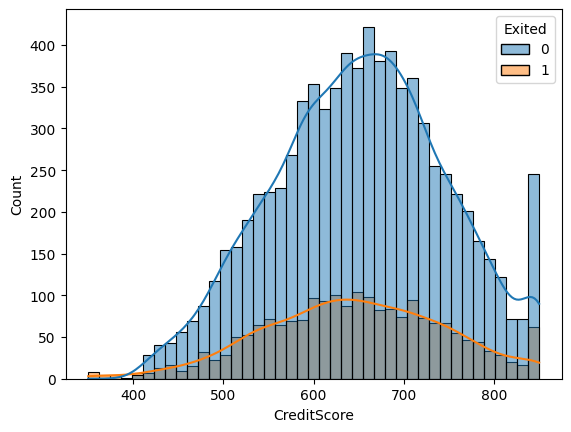

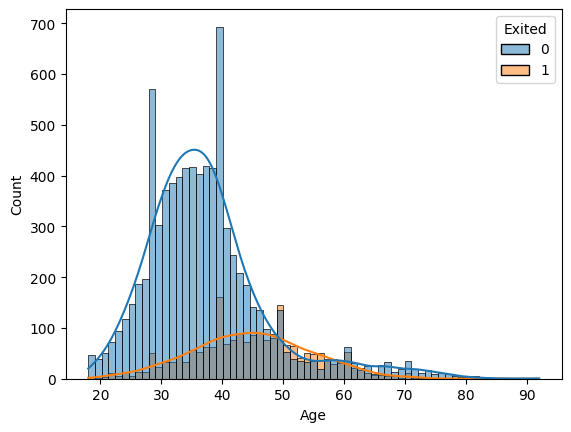

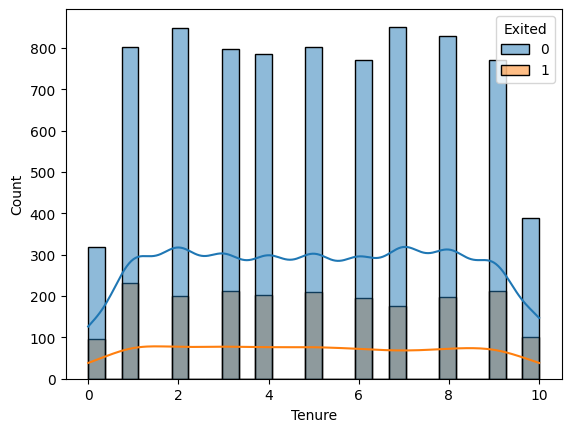

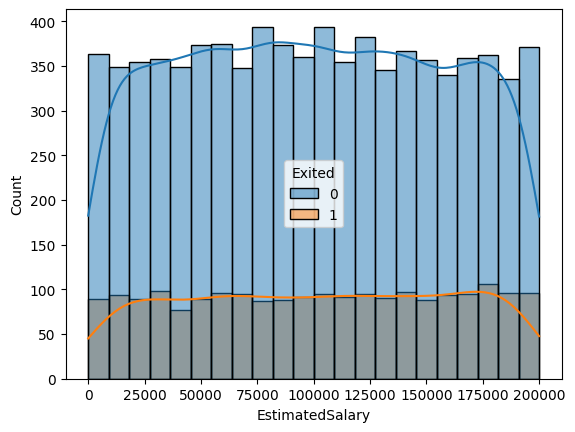

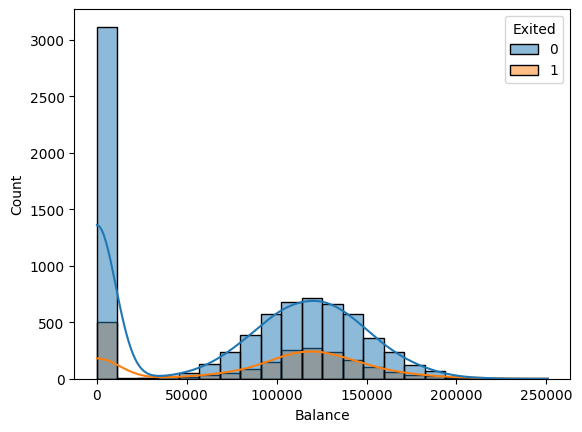

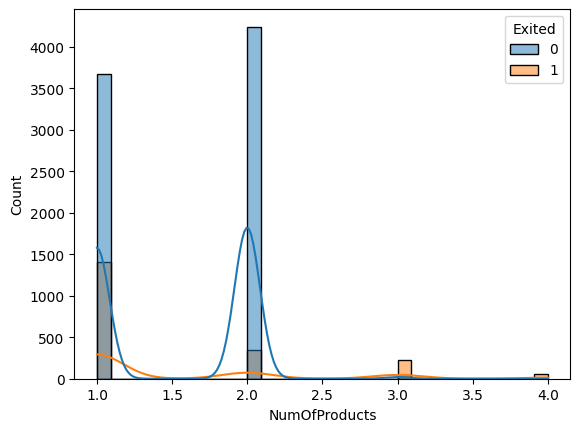

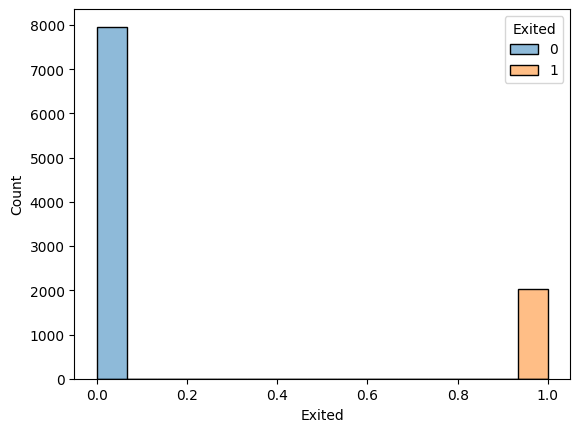

In [45]:
for col in churn_df.drop("CustomerId",axis=1).select_dtypes("number"):
    sns.histplot(data=churn_df,x=col,hue="Exited",kde=True)
    plt.show()

# Objective 4 : Prepare the data for modeling
## In this final objective , lets prepare the data for modeling through feature selection, feature engineering, and data splitting.

### Create a new dataset that excludes any columns that aren’t be suitable for modeling

In [48]:
churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,France,Female,42,2,101348.88,0.00,1,Yes,Yes,1
2,15647311,Hill,608,Spain,Female,41,1,112542.58,83807.86,1,Yes,Yes,0
3,15619304,Onio,502,France,Female,42,8,113931.57,159660.80,3,No,No,1
4,15701354,Boni,699,France,Female,39,1,93826.63,0.00,2,No,No,0
5,15737888,Mitchell,850,Spain,Female,43,2,79084.10,125510.82,1,Yes,Yes,0


In [49]:
modelling_df = churn_df.drop(['CustomerId','Surname'],axis=1)

modelling_df.head()

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,619,France,Female,42,2,101348.88,0.00,1,Yes,Yes,1
2,608,Spain,Female,41,1,112542.58,83807.86,1,Yes,Yes,0
3,502,France,Female,42,8,113931.57,159660.80,3,No,No,1
4,699,France,Female,39,1,93826.63,0.00,2,No,No,0
5,850,Spain,Female,43,2,79084.10,125510.82,1,Yes,Yes,0


### Create dummy variables for categorical fields

In [51]:
modelling_df = pd.get_dummies(modelling_df,drop_first=True)

### Create a new “balance_v_income” feature, which divides a customer’s bank balance by their estimated salary, then visualize that feature vs. churn status

In [52]:
modelling_df['balance_v_income'] = modelling_df['Balance']/modelling_df['EstimatedSalary']

modelling_df.head()

,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard_Yes,IsActiveMember_Yes,balance_v_income
0,619,42,2,101348.88,0.00,1,1,False,False,False,True,True,0.000000
2,608,41,1,112542.58,83807.86,1,0,False,True,False,True,True,0.744677
3,502,42,8,113931.57,159660.80,3,1,False,False,False,False,False,1.401375
4,699,39,1,93826.63,0.00,2,0,False,False,False,False,False,0.000000
5,850,43,2,79084.10,125510.82,1,0,False,True,False,True,True,1.587055


<Axes: ylabel='balance_v_income'>

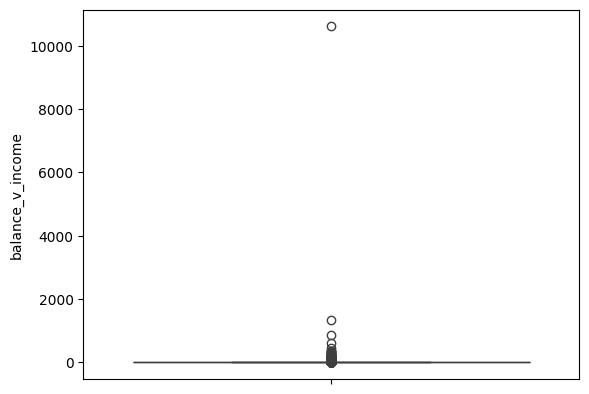

In [54]:
sns.boxplot(data=modelling_df, y= 'balance_v_income')

In [55]:
modelling_df.describe()

,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited,balance_v_income
count,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.9215,5.012800,100092.252506,76485.889288,1.530200,0.203700,3.878703
std,96.653299,10.487552,2.892174,57510.146401,62397.405202,0.581654,0.402769,108.337260
min,350.000000,18.0,0.000000,11.580000,0.000000,1.000000,0.000000,0.000000
25%,584.000000,32.0,3.000000,51002.110000,0.000000,1.000000,0.000000,0.000000
50%,652.000000,37.0,5.000000,100196.062500,97198.540000,1.000000,0.000000,0.747002
75%,718.000000,44.0,7.000000,149388.247500,127644.240000,2.000000,0.000000,1.514022
max,850.000000,92.0,10.000000,199992.480000,250898.090000,4.000000,1.000000,10614.655440


<Axes: ylabel='balance_v_income'>

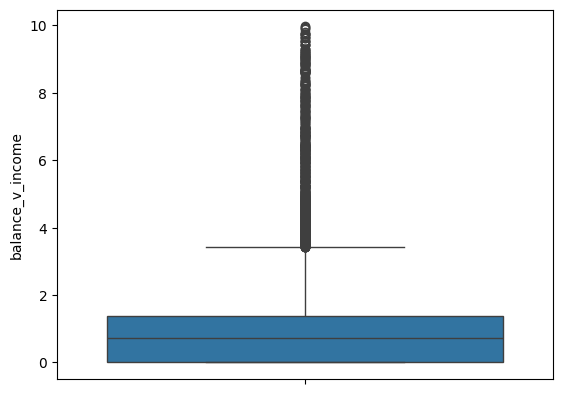

In [56]:
sns.boxplot(data=modelling_df.query('balance_v_income < 10'), y= 'balance_v_income')

<Axes: ylabel='balance_v_income'>

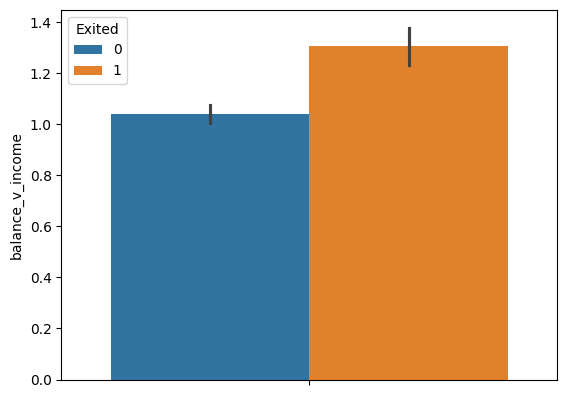

In [57]:
sns.barplot(data=modelling_df.query('balance_v_income < 10'), y= 'balance_v_income',hue = 'Exited')